# Predicting Hazardous Seismic Bumps in Coal Mines

**A safety-first machine-learning study on the UCI Seismic Bumps dataset**

---

## Abstract

Rockbursts are sudden, destructive releases of energy in underground coal mines and
are a serious threat to miner safety. This notebook builds and evaluates a classifier
that flags whether the **next work shift** is likely to be *hazardous* (a high-energy
seismic event) based on geophysical readings from the current shift.

The central difficulty is **class imbalance**: only about **6.6%** of shifts are
hazardous. A model that simply predicts "safe" every time would be 93% accurate yet
completely useless for safety. We therefore optimise for **recall** and the
**F2 score** (which weights recall four times more than precision) rather than raw
accuracy, because *missing* a dangerous shift is far costlier than raising a false
alarm.

**What we do, in order:** load and explore the data, build a leakage-safe
preprocessing pipeline, train and fairly compare four model families, study how to
handle the imbalance, calibrate the probabilities so they can be read as real risk,
and finally select a transparent operating policy with a cost-based decision threshold.

> **How to read this notebook.** Every section opens with a plain-language explanation
> of *what* we are doing and *why*. The code cells are deliberately short — the heavy
> lifting lives in the project's helper modules (`load_arff.py`, `preprocess.py`, `metrics.py`, …), and the cells simply call them. You can
> understand the entire study by reading top to bottom, without opening any other file.

## Contents

1. [Setup](#1.-Setup)
2. [Loading the data](#2.-Loading-the-data)
3. [Exploratory data analysis](#3.-Exploratory-data-analysis)
4. [Train / validation / test split](#4.-Train-/-validation-/-test-split)
5. [Preprocessing](#5.-Preprocessing)
6. [Baseline model: Logistic Regression](#6.-Baseline-model:-Logistic-Regression)
7. [Comparing four model families](#7.-Comparing-four-model-families)
8. [Handling class imbalance](#8.-Handling-class-imbalance)
9. [Probability calibration](#9.-Probability-calibration)
10. [Final operating policy](#10.-Final-operating-policy)
11. [Conclusion and limitations](#11.-Conclusion-and-limitations)

## 1. Setup

We import the standard scientific-Python stack and make the project's helper modules
importable by adding the repository root to the path. We also fix a single random seed
(`RANDOM_STATE = 42`) so every result in this notebook is **reproducible** — rerunning
the notebook produces identical splits, models, and numbers.

In [1]:
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

REPO_ROOT = Path.cwd()

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 120)
plt.rcParams["figure.figsize"] = (8, 4.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

print("Setup complete. Random seed fixed at", RANDOM_STATE, "for reproducibility.")

Setup complete. Random seed fixed at 42 for reproducibility.


## 2. Loading the data

The dataset is the **UCI Seismic Bumps** collection: 2,584 shifts described by 18
features plus a binary target (`class`: 0 = non-hazardous, 1 = hazardous). It ships
with the repository under `data/raw/`, so this notebook runs anywhere with no manual
download.

We reuse the project loader `load_seismic_bumps()`
([`load_arff.py`](load_arff.py)), which reads the ARFF file,
decodes its byte-string categoricals to normal text, and converts the target to a clean
integer.

In [2]:
from scipy.io import arff

def load_seismic_bumps(path):
    """Load seismic-bumps.arff and return a clean DataFrame.

    - Decode byte-string categoricals (ARFF returns them as b'a', etc.) to UTF-8.
    - Convert the 'class' target to int (0 = non-hazardous, 1 = hazardous).
    Returns a DataFrame of shape (2584, 19).
    """
    data, meta = arff.loadarff(path)
    df = pd.DataFrame(data)
    for col in df.select_dtypes(include=[object]).columns:
        df[col] = df[col].str.decode("utf-8")
    df["class"] = df["class"].astype(int)
    return df

ARFF_PATH = REPO_ROOT / "data" / "raw" / "seismic-bumps.arff"

df = load_seismic_bumps(ARFF_PATH)
print(f"Dataset shape: {df.shape[0]} shifts x {df.shape[1]} columns")
df.head()

Dataset shape: 2584 shifts x 19 columns


,seismic,seismoacoustic,shift,genergy,gpuls,gdenergy,gdpuls,ghazard,nbumps,nbumps2,nbumps3,nbumps4,nbumps5,nbumps6,nbumps7,nbumps89,energy,maxenergy,class
0,a,a,N,15180.0,48.0,-72.0,-72.0,a,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
1,a,a,N,14720.0,33.0,-70.0,-79.0,a,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,2000.0,2000.0,0
2,a,a,N,8050.0,30.0,-81.0,-78.0,a,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
3,a,a,N,28820.0,171.0,-23.0,40.0,a,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,3000.0,3000.0,0
4,a,a,N,12640.0,57.0,-63.0,-52.0,a,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0


In [3]:
df.dtypes.to_frame("dtype")

,dtype
seismic,str
seismoacoustic,str
shift,str
genergy,float64
gpuls,float64
gdenergy,float64
gdpuls,float64
ghazard,str
nbumps,float64
nbumps2,float64


## 3. Exploratory data analysis

### 3.1 The class imbalance — the defining challenge

Before modelling, we look at how many shifts are actually hazardous. This single fact
shapes every decision that follows.

Non-hazardous (0): 2414  (93.4%)
Hazardous     (1):  170  (6.6%)
Imbalance ratio  : 14.2 : 1


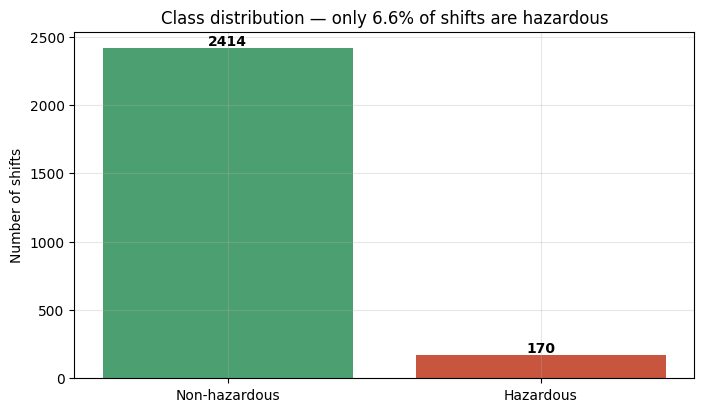

In [4]:
counts = df["class"].value_counts().sort_index()
rate = df["class"].mean()
print(f"Non-hazardous (0): {counts[0]:>4}  ({100*(1-rate):.1f}%)")
print(f"Hazardous     (1): {counts[1]:>4}  ({100*rate:.1f}%)")
print(f"Imbalance ratio  : {counts[0]/counts[1]:.1f} : 1")

fig, ax = plt.subplots()
ax.bar(["Non-hazardous", "Hazardous"], counts.values, color=["#4C9F70", "#C8553D"])
for i, v in enumerate(counts.values):
    ax.text(i, v + 20, str(v), ha="center", fontweight="bold")
ax.set_ylabel("Number of shifts")
ax.set_title(f"Class distribution — only {100*rate:.1f}% of shifts are hazardous")
plt.show()

**What this shows.** Hazardous shifts are rare — roughly a 1-in-15 event. A model that
always predicts "safe" would score ~93% accuracy while catching *zero* dangerous shifts.
This is exactly why we judge models by **recall** and **F2**, not accuracy.

### 3.2 Numeric features at a glance

In [5]:
numeric_cols = [
    "genergy", "gpuls", "gdenergy", "gdpuls", "energy", "maxenergy",
    "nbumps", "nbumps2", "nbumps3", "nbumps4", "nbumps5", "nbumps6", "nbumps7", "nbumps89",
]
df[numeric_cols].describe().T[["mean", "std", "min", "50%", "max"]]

,mean,std,min,50%,max
genergy,90242.523220,229200.508894,100.0,25485.0,2595650.0
gpuls,538.579334,562.652536,2.0,379.0,4518.0
gdenergy,12.375774,80.319051,-96.0,-6.0,1245.0
gdpuls,4.508901,63.166556,-96.0,-6.0,838.0
energy,4975.270898,20450.833222,0.0,0.0,402000.0
maxenergy,4278.850619,19357.454882,0.0,0.0,400000.0
nbumps,0.859520,1.364616,0.0,0.0,9.0
nbumps2,0.393576,0.783772,0.0,0.0,8.0
nbumps3,0.392802,0.769710,0.0,0.0,7.0
nbumps4,0.067724,0.279059,0.0,0.0,3.0


**What this shows.** The energy/pulse features (`genergy`, `gpuls`, `energy`,
`maxenergy`) are highly skewed with very large maxima — typical of seismic energy. The
higher-order bump counts (`nbumps6`, `nbumps7`, `nbumps89`) are almost always zero: such
large tremors are rare. These sparse columns carry little signal but we keep them so the
pipeline matches the raw data schema.

### 3.3 How hazardous vs. safe shifts differ

We compare the average feature values for the two classes (z-scored so different units
are comparable). Bars far from zero are features that separate the classes.

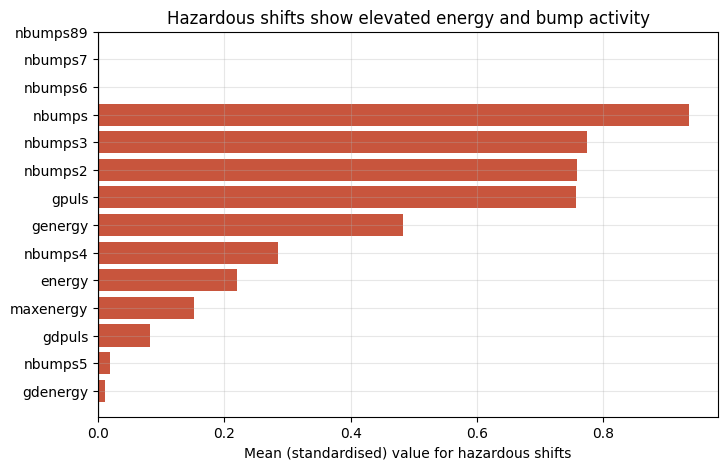

In [6]:
z = (df[numeric_cols] - df[numeric_cols].mean()) / df[numeric_cols].std()
diff = z.groupby(df["class"]).mean().T
diff.columns = ["Non-hazardous", "Hazardous"]
order = diff["Hazardous"].sort_values().index

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(range(len(order)), diff.loc[order, "Hazardous"], color="#C8553D")
ax.set_yticks(range(len(order)))
ax.set_yticklabels(order)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Mean (standardised) value for hazardous shifts")
ax.set_title("Hazardous shifts show elevated energy and bump activity")
plt.show()

**What this shows.** Hazardous shifts tend to have higher seismic energy and more
recorded bumps — physically sensible, and reassuring that the features carry real signal.

### 3.4 Feature correlations

Finally, a correlation heatmap of the numeric features. Strongly correlated groups
(e.g. the energy family) mean some features are partly redundant — relevant when we
later prefer a simple, regularised model.

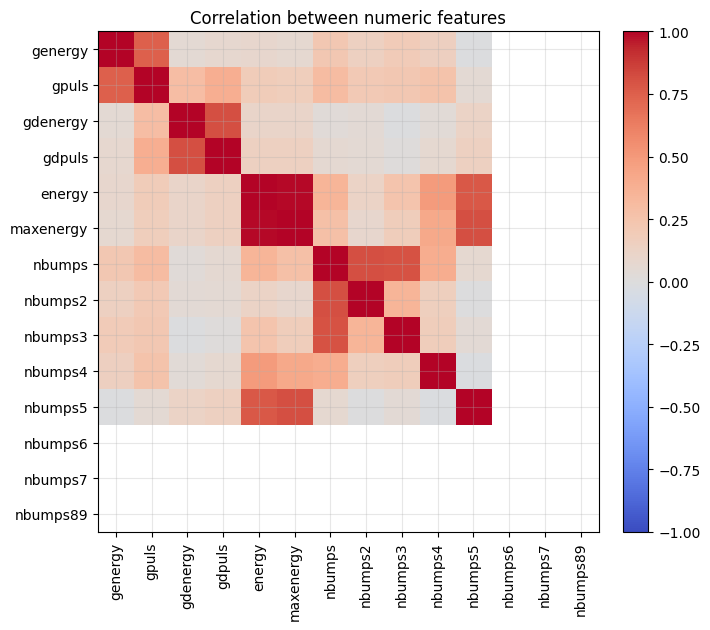

In [7]:
corr = df[numeric_cols].corr()
fig, ax = plt.subplots(figsize=(8, 6.5))
im = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(numeric_cols)))
ax.set_xticklabels(numeric_cols, rotation=90)
ax.set_yticks(range(len(numeric_cols)))
ax.set_yticklabels(numeric_cols)
fig.colorbar(im, fraction=0.046, pad=0.04)
ax.set_title("Correlation between numeric features")
plt.show()

## 4. Train / validation / test split

We split the data **70% / 15% / 15%** into train, validation, and test sets using the
project's `make_splits()` ([`splits.py`](splits.py)). Two points
matter for a credible evaluation:

- **Stratified** — each split keeps the same ~6.6% hazardous rate, so the rare class is
  represented everywhere.
- **Three-way** — we tune the decision threshold on the *validation* set and touch the
  *test* set only once, at the very end. This prevents us from accidentally tuning to the
  test data (a common source of over-optimistic results).

*Caveat (from the source code):* the dataset has no timestamps, so a strict
time-ordered split isn't possible; stratified random splitting is the best available
alternative.

In [8]:
from sklearn.model_selection import train_test_split

TARGET_COL = "class"

def make_splits(df, random_state=RANDOM_STATE):
    """Stratified 70/15/15 train / validation / test split.

    The dataset has no timestamps or shift identifiers, so strict time-ordered
    splitting is not possible; stratified random splitting (which preserves the
    ~6.6% hazardous rate in every split) is the best available alternative.
    """
    X = df.drop(columns=[TARGET_COL])
    y = df[TARGET_COL]

    X_trainval, X_test, y_trainval, y_test = train_test_split(
        X, y, test_size=0.15, stratify=y, random_state=random_state
    )
    X_train, X_val, y_train, y_val = train_test_split(
        X_trainval, y_trainval, test_size=15 / 85,
        stratify=y_trainval, random_state=random_state,
    )
    return {
        "train": (X_train, y_train),
        "validation": (X_val, y_val),
        "test": (X_test, y_test),
    }

splits = make_splits(df, random_state=RANDOM_STATE)
X_train, y_train = splits["train"]
X_val,   y_val   = splits["validation"]
X_test,  y_test  = splits["test"]

summary = pd.DataFrame(
    {
        "rows": [len(y_train), len(y_val), len(y_test)],
        "hazardous": [int(y_train.sum()), int(y_val.sum()), int(y_test.sum())],
        "hazardous_rate": [y_train.mean(), y_val.mean(), y_test.mean()],
    },
    index=["train", "validation", "test"],
)
summary["hazardous_rate"] = summary["hazardous_rate"].map("{:.3f}".format)
summary

,rows,hazardous,hazardous_rate
train,1808,119,0.066
validation,388,25,0.064
test,388,26,0.067


**What this shows.** All three splits hold a ~0.06 hazardous rate — stratification
worked, so the rare positive class is present in train, validation, and test alike.

## 5. Preprocessing

Raw features need encoding before modelling. We reuse `build_pipeline()`
([`preprocess.py`](preprocess.py)), which returns an
**unfitted** scikit-learn pipeline that:

- **ordinal-encodes** the ordered hazard ratings (`seismic`, `seismoacoustic`,
  `ghazard`) with the natural order `a < b < c < d`;
- **encodes** the binary `shift` column (`N`, `W`);
- **standard-scales** the numeric features for scale-sensitive models (Logistic
  Regression, SVM), or passes them through for tree models (Random Forest, XGBoost).

**Avoiding leakage.** The pipeline is *fit on the training split only* and then merely
*applied* to validation and test. This guarantees no information from the held-out data
leaks into preprocessing — a subtle but critical correctness requirement.

In [9]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OrdinalEncoder, StandardScaler

ORDINAL_COLS = ["seismic", "seismoacoustic", "ghazard"]
BINARY_COLS = ["shift"]
NUMERIC_COLS = [
    "genergy", "gpuls", "gdenergy", "gdpuls", "energy", "maxenergy",
    "nbumps", "nbumps2", "nbumps3", "nbumps4", "nbumps5", "nbumps6",
    "nbumps7", "nbumps89",
]
SCALED_MODELS = {"logreg", "svm"}

def build_pipeline(model_type, numeric_cols=NUMERIC_COLS):
    """Return an UNFITTED preprocessing Pipeline for the given model family.

    Ordinal-encodes the ordered categoricals, binary-encodes 'shift', and either
    standardizes (logreg/svm) or passes through (rf/xgboost) the numeric columns.
    Returned unfitted so the caller fits it on TRAIN only (no leakage).
    """
    ordinal = OrdinalEncoder(
        categories=[["a", "b", "c", "d"]] * 3,
        handle_unknown="use_encoded_value", unknown_value=-1,
    )
    binary = OrdinalEncoder(
        categories=[["N", "W"]],
        handle_unknown="use_encoded_value", unknown_value=-1,
    )
    numeric = StandardScaler() if model_type in SCALED_MODELS else "passthrough"
    preprocessor = ColumnTransformer(
        transformers=[
            ("ordinal", ordinal, ORDINAL_COLS),
            ("binary", binary, BINARY_COLS),
            ("numeric", numeric, numeric_cols),
        ],
        remainder="drop",
    )
    return Pipeline(steps=[("preprocessor", preprocessor)])

demo = build_pipeline("logreg")
X_train_enc = demo.fit_transform(X_train)
X_val_enc   = demo.transform(X_val)
print("Encoded training matrix shape:", X_train_enc.shape)
print("All numeric now? ", np.issubdtype(X_train_enc.dtype, np.number))
print("First encoded row (rounded):", np.round(X_train_enc[0], 2))

Encoded training matrix shape: (1808, 18)
All numeric now?  True
First encoded row (rounded): [ 1.    1.    1.    1.   -0.3   0.08  0.54  0.45 -0.24 -0.22 -0.64 -0.51
 -0.51 -0.24 -0.07  0.    0.    0.  ]


## 6. Baseline model: Logistic Regression

We start with a **Logistic Regression** baseline — simple, fast, and interpretable. Two
ideas appear here that recur throughout:

- **`class_weight="balanced"`** tells the model to pay proportionally more attention to
  the rare hazardous class, counteracting the imbalance.
- **Threshold selection.** A classifier outputs a *probability*; we must choose a cutoff
  above which we raise an alarm. The default 0.5 is wrong for imbalanced safety problems.
  We use `select_threshold()` ([`metrics.py`](metrics.py)) to
  pick the cutoff that **maximises F2 on the validation set**, then evaluate that fixed
  cutoff once on the test set.

*Glossary.* **Recall** = of all truly hazardous shifts, the fraction we flagged (miss
rate's complement). **Precision** = of the shifts we flagged, the fraction truly
hazardous. **F2** = a blend of the two that weights recall 4x — the right summary when
misses are much costlier than false alarms.

In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, confusion_matrix, fbeta_score,
    precision_recall_fscore_support, roc_auc_score,
)

def compute_metrics(y_true, y_pred, y_score=None, threshold=0.5):
    """Hazardous-class metric suite. The positive class (1) is 'hazardous'."""
    prec, rec, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, pos_label=1, average="binary", zero_division=0
    )
    f2 = fbeta_score(y_true, y_pred, beta=2, pos_label=1, zero_division=0)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    roc = roc_auc_score(y_true, y_score) if y_score is not None else None
    return {
        "hazardous_precision": float(prec), "hazardous_recall": float(rec),
        "hazardous_f1": float(f1), "hazardous_f2": float(f2),
        "roc_auc": float(roc) if roc is not None else None,
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "tn": int(tn), "fp": int(fp), "fn": int(fn), "tp": int(tp),
        "threshold": float(threshold),
    }

def select_threshold(y_val_true, y_val_score, beta=2.0):
    """Pick the threshold maximizing hazardous F-beta on the validation set.

    Ties (within 0.01 F-beta) break toward higher recall, then toward 0.5.
    """
    y_val_true = np.asarray(y_val_true)
    y_val_score = np.asarray(y_val_score)
    best_fbeta, best_recall, best_thresh = -1.0, -1.0, 0.5
    for t in np.linspace(0.01, 0.99, 99):
        y_pred = (y_val_score >= t).astype(int)
        fb = fbeta_score(y_val_true, y_pred, beta=beta, pos_label=1, zero_division=0)
        rec = float(np.sum((y_pred == 1) & (y_val_true == 1))) / max(np.sum(y_val_true == 1), 1)
        if fb > best_fbeta + 0.01:
            best_fbeta, best_recall, best_thresh = fb, rec, t
        elif abs(fb - best_fbeta) <= 0.01:
            if rec > best_recall:
                best_recall, best_thresh = rec, t
            elif rec == best_recall and abs(t - 0.5) < abs(best_thresh - 0.5):
                best_thresh = t
    return float(best_thresh)

logreg = build_pipeline("logreg")
logreg.steps.append(
    ("classifier", LogisticRegression(class_weight="balanced", max_iter=1000, solver="lbfgs"))
)
logreg.fit(X_train, y_train)

val_scores = logreg.predict_proba(X_val)[:, 1]
threshold = select_threshold(y_val, val_scores, beta=2.0)
print(f"F2-optimal threshold (chosen on validation): {threshold:.3f}")

test_scores = logreg.predict_proba(X_test)[:, 1]
test_pred = (test_scores >= threshold).astype(int)
baseline_metrics = compute_metrics(y_test, test_pred, y_score=test_scores, threshold=threshold)

pd.Series(
    {
        "recall (hazardous)":    baseline_metrics["hazardous_recall"],
        "precision (hazardous)": baseline_metrics["hazardous_precision"],
        "F2":                    baseline_metrics["hazardous_f2"],
        "ROC-AUC":               baseline_metrics["roc_auc"],
        "accuracy":              baseline_metrics["accuracy"],
    }
).round(3).to_frame("test score")

F2-optimal threshold (chosen on validation): 0.550


,test score
recall (hazardous),0.577
precision (hazardous),0.214
F2,0.431
ROC-AUC,0.737
accuracy,0.830


**What this shows.** With balanced weighting and an F2-tuned threshold, the baseline
already catches a majority of hazardous shifts (high recall) at the cost of many false
alarms (low precision) — the trade-off we *want* in a safety system. Note how modest the
accuracy looks compared to the trivial 93% "always-safe" baseline: accuracy is the wrong
lens here.

## 7. Comparing four model families

Is a more complex model worth it? We compare four families on the **same splits, same
metrics, same threshold-selection rule** so the comparison is fair:

- **Logistic Regression** — linear, interpretable (our baseline).
- **Random Forest** — an ensemble of decision trees; robust, non-linear.
- **SVM (RBF)** — maximum-margin classifier with a non-linear kernel.
- **XGBoost** — gradient-boosted trees; a strong tabular learner.

Each model's hyperparameters are tuned with `RandomizedSearchCV` (5-fold,
F2-scored) on the training set; the threshold is then chosen on validation and the model
is scored once on test. This mirrors `scripts/train_all_models.py`, condensed into one
reusable helper so the logic is readable.

In [11]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import make_scorer, fbeta_score
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier

f2_scorer = make_scorer(fbeta_score, beta=2, pos_label=1)

def train_and_score(model_type, classifier, param_grid, use_decision_function=False):
    pipe = Pipeline(list(build_pipeline(model_type).steps) + [("classifier", classifier)])
    search = RandomizedSearchCV(
        pipe, param_grid, n_iter=20, cv=5, scoring=f2_scorer,
        random_state=RANDOM_STATE, n_jobs=-1,
    )
    search.fit(X_train, y_train)
    best = search.best_estimator_

    score = (lambda X: best.decision_function(X)) if use_decision_function \
            else (lambda X: best.predict_proba(X)[:, 1])
    thr = select_threshold(y_val, score(X_val), beta=2.0)
    test_pred = (score(X_test) >= thr).astype(int)
    m = compute_metrics(y_test, test_pred, y_score=score(X_test), threshold=thr)
    m["threshold"] = thr
    return m

print("Training models (this runs real hyperparameter searches; ~1-2 minutes)...")

Training models (this runs real hyperparameter searches; ~1-2 minutes)...


In [12]:
results = {
    "Logistic Regression": baseline_metrics | {"threshold": threshold},
}

results["Random Forest"] = train_and_score(
    "rf",
    RandomForestClassifier(random_state=RANDOM_STATE),
    {
        "classifier__n_estimators": [200, 400, 600],
        "classifier__max_depth": [None, 8, 16, 24],
        "classifier__min_samples_split": [2, 5, 10],
        "classifier__min_samples_leaf": [1, 2, 4],
        "classifier__max_features": ["sqrt", "log2", 0.5],
        "classifier__class_weight": [None, "balanced"],
    },
)

results["SVM (RBF)"] = train_and_score(
    "svm",
    SVC(kernel="rbf", class_weight="balanced", random_state=RANDOM_STATE),
    {"classifier__C": [0.1, 1, 10, 100], "classifier__gamma": ["scale", 0.01, 0.1, 1.0]},
    use_decision_function=True,
)

n_neg, n_pos = int((y_train == 0).sum()), int((y_train == 1).sum())
results["XGBoost"] = train_and_score(
    "xgboost",
    XGBClassifier(scale_pos_weight=n_neg / n_pos, random_state=RANDOM_STATE, eval_metric="logloss"),
    {
        "classifier__n_estimators": [100, 200, 300],
        "classifier__max_depth": [3, 5, 7],
        "classifier__learning_rate": [0.03, 0.05, 0.1],
        "classifier__subsample": [0.7, 0.85, 1.0],
        "classifier__colsample_bytree": [0.7, 0.85, 1.0],
        "classifier__min_child_weight": [1, 3, 5],
    },
)
print("Done.")

Done.


In [13]:
comparison = pd.DataFrame(
    {
        name: {
            "threshold": m["threshold"],
            "recall": m["hazardous_recall"],
            "precision": m["hazardous_precision"],
            "F2": m["hazardous_f2"],
            "ROC-AUC": m["roc_auc"],
            "accuracy": m["accuracy"],
        }
        for name, m in results.items()
    }
).T.round(3)
comparison.sort_values("F2", ascending=False)

,threshold,recall,precision,F2,ROC-AUC,accuracy
XGBoost,0.66,0.462,0.353,0.435,0.763,0.907
Logistic Regression,0.55,0.577,0.214,0.431,0.737,0.830
SVM (RBF),0.11,0.577,0.205,0.424,0.713,0.822
Random Forest,0.50,0.423,0.355,0.407,0.763,0.910


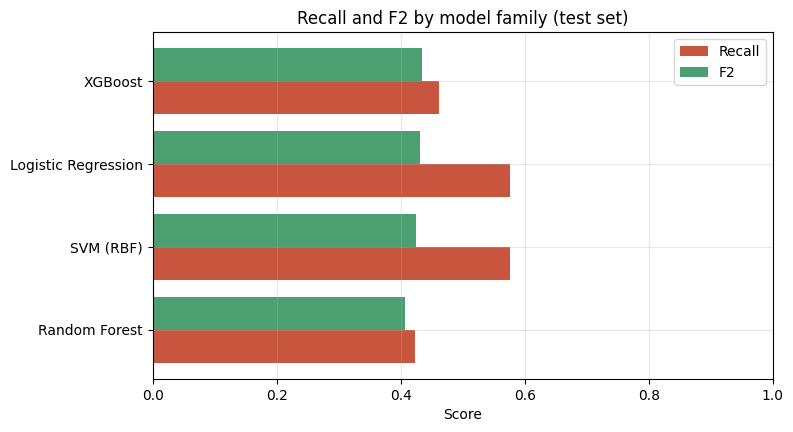

In [14]:
fig, ax = plt.subplots(figsize=(8, 4.5))
plot_df = comparison.sort_values("F2")
x = np.arange(len(plot_df))
ax.barh(x - 0.2, plot_df["recall"], height=0.4, label="Recall", color="#C8553D")
ax.barh(x + 0.2, plot_df["F2"],     height=0.4, label="F2",     color="#4C9F70")
ax.set_yticks(x); ax.set_yticklabels(plot_df.index)
ax.set_xlabel("Score"); ax.set_xlim(0, 1)
ax.set_title("Recall and F2 by model family (test set)")
ax.legend()
plt.show()

**What this shows.** The models land in a similar F2 range — the extra complexity of
trees and boosting does **not** decisively beat the simple linear baseline on this small,
imbalanced dataset. Given comparable performance, the project favours **Logistic
Regression**: it is interpretable, stable, fast, and produces well-behaved probabilities
that we can calibrate (next sections) — exactly what a safety-critical, auditable system
should prefer. *(Exact numbers can shift slightly with library versions; the committed
`artifacts/model_metrics.csv` is the reference run.)*

## 8. Handling class imbalance

We saw that the right *metric* (F2) and the right *threshold* matter. A third lever is
**how we treat the imbalance during training**. The project ran a dedicated experiment
(`scripts/run_imbalance_experiments.py`) comparing strategies:

- **default** — no special handling;
- **class_weight = "balanced"** — reweight the loss toward the rare class;
- **SMOTE** — synthetically oversample hazardous examples;
- **SMOTE + balanced** — both together.

Rather than re-run that whole sweep here, we load its recorded results so the conclusion
is reproducible and fast to read.

In [15]:
imb = pd.read_csv(REPO_ROOT / "artifacts" / "imbalance_experiments.csv")
imb_test = imb[imb["split"] == "test"][
    ["model", "imbalance_strategy", "threshold",
     "hazardous_recall", "hazardous_precision", "hazardous_f2", "roc_auc"]
].round(3).reset_index(drop=True)
imb_test

,model,imbalance_strategy,threshold,hazardous_recall,hazardous_precision,hazardous_f2,roc_auc
0,logreg,default,0.07,0.577,0.169,0.389,0.745
1,logreg,class_weight_balanced,0.55,0.577,0.214,0.431,0.737
2,logreg,smote,0.55,0.577,0.197,0.417,0.751
3,logreg,smote_balanced,0.55,0.577,0.197,0.417,0.751
4,random_forest,default,0.07,0.615,0.160,0.392,0.724
5,random_forest,class_weight_balanced,0.50,0.423,0.355,0.407,0.763
6,random_forest,smote,0.21,0.577,0.179,0.399,0.713
7,random_forest,smote_balanced,0.21,0.577,0.179,0.399,0.713


**What this shows.** Simple **class weighting** is competitive with — and simpler than —
SMOTE-based oversampling. SMOTE adds synthetic data and complexity without a reliable F2
payoff on this dataset. This supports the final choice of a balanced-weight Logistic
Regression with no synthetic oversampling.

## 9. Probability calibration

For a safety dashboard we want the model's output to mean what it says: when it reports
"15% risk", roughly 15% of such shifts should truly be hazardous. Raw classifier scores
are often **miscalibrated**. We fix this with `CalibratedClassifierCV` (isotonic
regression) and check the result two ways:

- a **reliability diagram** — predicted probability vs. observed frequency; the closer to
  the diagonal, the better;
- the **Brier score** — mean squared error of the probabilities (lower is better).

This mirrors `scripts/evaluate_calibration.py`.

Brier score  raw: 0.1757
Brier score  cal: 0.0583  (lower is better)


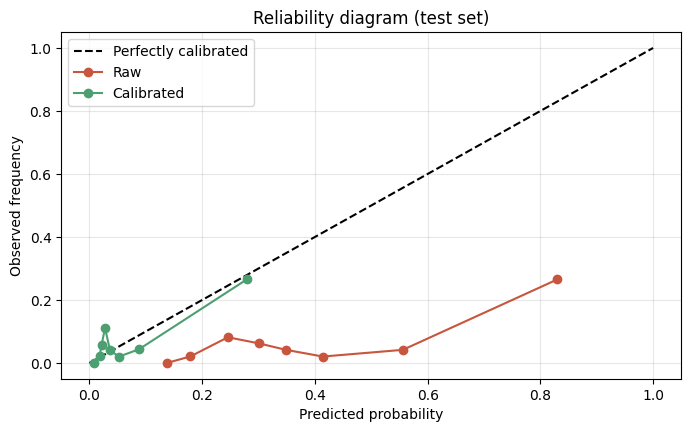

In [16]:
from sklearn.calibration import CalibratedClassifierCV
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss

base = Pipeline(list(build_pipeline("logreg").steps) +
                [("classifier", LogisticRegression(class_weight="balanced", max_iter=1000))])
calibrated = CalibratedClassifierCV(base, method="isotonic", cv=5)
calibrated.fit(X_train, y_train)

raw_p   = logreg.predict_proba(X_test)[:, 1]
cal_p   = calibrated.predict_proba(X_test)[:, 1]
print(f"Brier score  raw: {brier_score_loss(y_test, raw_p):.4f}")
print(f"Brier score  cal: {brier_score_loss(y_test, cal_p):.4f}  (lower is better)")

fig, ax = plt.subplots()
ax.plot([0, 1], [0, 1], "k--", label="Perfectly calibrated")
for p, lbl, c in [(raw_p, "Raw", "#C8553D"), (cal_p, "Calibrated", "#4C9F70")]:
    frac_pos, mean_pred = calibration_curve(y_test, p, n_bins=8, strategy="quantile")
    ax.plot(mean_pred, frac_pos, "o-", label=lbl, color=c)
ax.set_xlabel("Predicted probability"); ax.set_ylabel("Observed frequency")
ax.set_title("Reliability diagram (test set)"); ax.legend()
plt.show()

**What this shows.** After isotonic calibration the curve sits closer to the diagonal and
the Brier score improves, so the reported risk percentages are trustworthy enough to drive
the watch/danger thresholds used in the deployed app.

## 10. Final operating policy

The project freezes a transparent decision policy in
[`artifacts/final_policy/final_policy.json`](artifacts/final_policy/final_policy.json).
The key idea is a **cost-based threshold**: a missed hazardous shift (false negative) is
treated as **10x** costlier than a false alarm (false positive), reflecting that miner
safety dominates inconvenience. The operating threshold is chosen to minimise that
expected cost on calibrated cross-validated scores.

The policy was confirmed on a held-out **"lockbox"** set (a final, untouched evaluation
sample) with **bootstrap 95% confidence intervals**, so we report not just point estimates
but the uncertainty around them.

In [17]:
policy = json.loads((REPO_ROOT / "artifacts" / "final_policy" / "final_policy.json").read_text())
print("Model            :", policy["model"], "/", policy["variant"])
print("Operating thresh :", policy["operating_threshold"])
print("Watch floor      :", policy["watch_floor"])
print("Cost ratio (FN:FP):", policy["cost_matrix"]["ratio"], ": 1")

cis = pd.read_csv(REPO_ROOT / "artifacts" / "final_policy" / "lockbox_metric_cis.csv")
cis = cis.set_index("metric")[["point_estimate", "ci_low", "ci_high"]].round(3)
cis

Model            : logreg / baseline_lockbox
Operating thresh : 0.08
Watch floor      : 0.04
Cost ratio (FN:FP): 10.0 : 1


,point_estimate,ci_low,ci_high
metric,,,
hazardous_recall,0.577,0.381,0.769
hazardous_precision,0.174,0.096,0.258
hazardous_f2,0.395,0.248,0.525
roc_auc,0.745,0.640,0.846


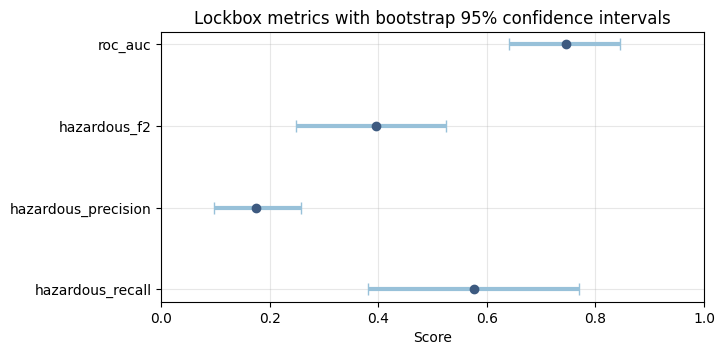

In [18]:
fig, ax = plt.subplots(figsize=(7, 3.5))
y = np.arange(len(cis))
ax.errorbar(
    cis["point_estimate"], y,
    xerr=[cis["point_estimate"] - cis["ci_low"], cis["ci_high"] - cis["point_estimate"]],
    fmt="o", color="#3D5A80", ecolor="#98C1D9", elinewidth=3, capsize=4,
)
ax.set_yticks(y); ax.set_yticklabels(cis.index)
ax.set_xlim(0, 1); ax.set_xlabel("Score")
ax.set_title("Lockbox metrics with bootstrap 95% confidence intervals")
plt.show()

**What this shows.** The frozen policy is a calibrated, balanced-weight Logistic
Regression operating at a low, cost-justified threshold so that it errs toward catching
hazardous shifts. The confidence intervals are wide — unavoidable given only ~26
hazardous shifts in the evaluation sample — which we state honestly rather than hide.

## 11. Conclusion and limitations

**Summary.** We built a safety-first classifier for hazardous coal-mine seismic shifts.
Because hazardous shifts are rare (~6.6%), we optimised **recall** and **F2** rather than
accuracy, used **balanced class weighting** and an **F2-tuned, cost-based threshold**,
**calibrated** the probabilities so they read as genuine risk, and selected a simple,
interpretable **Logistic Regression** policy that performs on par with more complex
models while being far easier to trust and audit.

**Key takeaways.**
- Accuracy is misleading under severe imbalance; recall/F2 with an explicit cost ratio is
  the honest objective.
- Model *complexity* did not pay off here — a regularised linear model matched trees and
  boosting.
- Calibration and a transparent, cost-based threshold turn a classifier into a usable
  safety tool.

**Limitations.**
- **No timestamps** in the dataset prevent true temporal validation; we used stratified
  random splits instead.
- **Very few positives** (~165 hazardous shifts total) make all estimates uncertain, as
  the wide confidence intervals show.
- Results are from one mining context and one historical period; deployment elsewhere
  would require re-validation.

**Where to go next.** The same trained policy powers an interactive Streamlit dashboard
(`streamlit_app.py`) for single-shift and batch scoring, and the project additionally
explores enriching predictions with external USGS seismic data — both beyond the scope of
this core analysis.